In [1]:
#Cell 1 — Imports
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Deep learning (Keras)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [3]:
#Cell 2 — Load dataset
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\customer_support_text_classification.csv")
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Task 1 — Dataset Understanding

We explore the dataset to understand:

- Number of records  
- Target labels  
- Sample text records 
- Average text length  
- Class distribution  


Number of records: 1500

Target labels: <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Sample records:


,ticket_id,customer_message,sentiment_label
0,TKT00001,I need information about the payment process. ...,neutral
1,TKT00002,I need information about the payment process.,neutral
2,TKT00003,The refund process was fast and convenient. I ...,positive
3,TKT00004,My refund is still pending and this experience...,negative
4,TKT00005,Please tell me how to update my account details.,neutral



Average text length: 12.722666666666667

Class distribution:


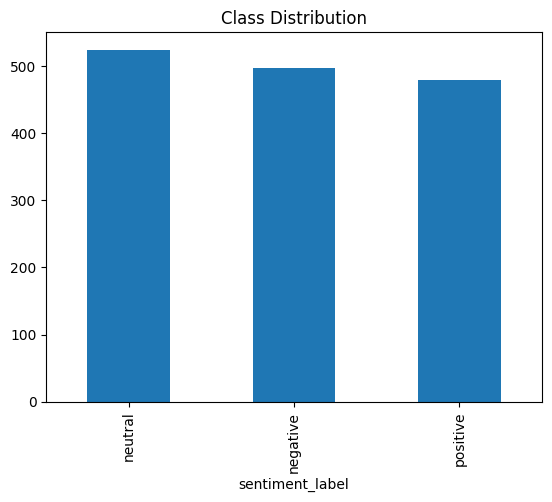

In [9]:
#Cell 3 — Basic understanding (Task 1)
print("Number of records:", len(df))

print("\nTarget labels:", df['sentiment_label'].unique())

print("\nSample records:")
display(df[['ticket_id', 'customer_message', 'sentiment_label']].head())

print("\nAverage text length:", df['word_count'].mean())

print("\nClass distribution:")
df['sentiment_label'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()



Task 2 — Text Preprocessing

Preprocessing includes:

- Lowercasing  
- Removing symbols & special characters  
- Tokenization  
- Optional stopword removal  
- Padding/truncation for sequence models  

We create a `clean_text` column for ML models and padded sequences for LSTM.


In [ ]:
#Cell 4 — Minimal Stopword List

stop_words = {
    "the","is","am","are","a","an","and","or","to","of","in","on","for","with",
    "this","that","it","as","be","by","from","at","was","were","but","so","if",
    "your","my","our","their","i","you","we","they"
}

In [ ]:
#Cell 5 — Clean Text Function

import re
import string

def clean_text(text, remove_stopwords=False):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove ticket numbers
    text = re.sub(r"ticket number is \d+", "ticket number", text)
    text = re.sub(r"my ticket number is \d+", "ticket number", text)

    # 3. Remove digits
    text = re.sub(r"\d+", "", text)

    # 4. Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 5. Tokenization
    tokens = text.split()

    # 6. Optional stopword removal
    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    # 7. Rejoin tokens
    text = " ".join(tokens)

    return text


In [ ]:
#Cell 6 — Apply Cleaning

df['clean_text'] = df['customer_message'].astype(str).apply(
    lambda x: clean_text(x, remove_stopwords=False)
)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


Tokenization & Padding (for LSTM)

We convert text into integer sequences and pad them to equal length.


In [ ]:
#Cell 7 — Tokenizer + Padding

max_words = 10000
max_len = 25

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

padded_sequences[:3]



array([[  4,  30, 137,  40,   2,  91,  34,   3,   7,   8,  11,  13,   9,
         14,   9,  15,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  4,  30, 137,  40,   2,  91,  34,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  2,  29,  34,  12,  58,   5,  59,   4,  31,   2,  32,  23,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],
      dtype=int32)

Task 3 — Text Vectorization

We use:

- TF‑IDF for baseline ML  
- Tokenizer sequences for LSTM  


In [14]:
#Cell 8 — TF‑IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = df['clean_text']
y = df['sentiment_label'].map({'negative':0,'neutral':1,'positive':2})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [16]:
## Task 4 — Baseline Model (Logistic Regression + TF‑IDF)

# Cell 9 — Baseline Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)

y_pred = log_reg.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



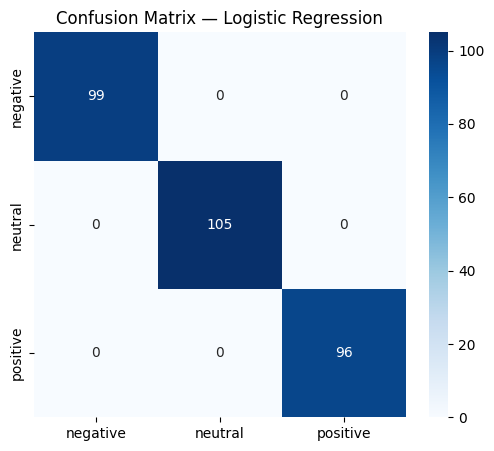

In [18]:
#Cell 10 — Confusion Matrix Plot
import os
os.makedirs("results", exist_ok=True)   # <-- FIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title("Confusion Matrix — Logistic Regression")

plt.savefig("results/model_evaluation.png", dpi=120)
plt.show()



In [19]:
##Task 5 — Sequence Model (LSTM)
#Cell 11 — Prepare Data for LSTM

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)



In [20]:
#Cell 12 — LSTM Model

model = Sequential([
    Embedding(max_words, 100, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Cell 13 — Train LSTM

history = model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6333 - loss: 1.0596 - val_accuracy: 0.8625 - val_loss: 0.9644
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8667 - loss: 0.7310 - val_accuracy: 0.9708 - val_loss: 0.3635
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9563 - loss: 0.2194 - val_accuracy: 1.0000 - val_loss: 0.0532
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9969 - loss: 0.0404 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 0.0018


In [22]:
#Cell 14 — Evaluate LSTM
y_pred_lstm = model.predict(X_test_pad).argmax(axis=1)

print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



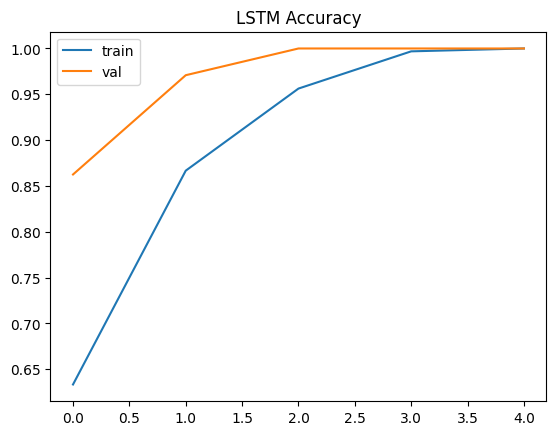

In [23]:
#Cell 15 — LSTM Accuracy Plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("LSTM Accuracy")
plt.legend()
plt.savefig("results/lstm_accuracy.png", dpi=120)
plt.show()


In [ ]:
##Task 6 — Attention & Transformer Reflection

(Write-up section)


In [24]:
#Cell 16 — Sample Predictions
import os
os.makedirs("results", exist_ok=True)

sample_idx = np.random.choice(len(X_test), 20, replace=False)

with open("results/sample_predictions.txt", "w") as f:
    for i in sample_idx:
        f.write(f"TEXT: {X_test.iloc[i]}\n")
        f.write(f"TRUE: {y_test.iloc[i]}\n")
        f.write(f"PRED: {y_pred[i]}\n")
        f.write("\n---\n")

print("Saved to results/sample_predictions.txt")


Saved to results/sample_predictions.txt
